## Inicialización

Te han ofrecido hacer prácticas en el departamento de analítica de Showz, una empresa de venta de entradas de eventos. Tu primera tarea es ayudar a optimizar los gastos de marketing.

Cuentas con:

- registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
- un archivo con los pedidos en este periodo;
- estadísticas de gastos de marketing.

Lo que vas a investigar:

- cómo los clientes usan el servicio;
- cuándo empiezan a comprar;
- cuánto dinero aporta cada cliente a la compañía;
- cuándo los ingresos cubren el costo de adquisición de los clientes.


### **Instrucciones para completar el proyecto**

**Paso 1. Acceda los datos y prepáralos para el análisis**

Almacena los datos de visitas, pedidos y gastos en variables.  Optimiza los datos para el análisis. Asegúrate de que cada columna contenga el tipo de datos correcto. 
Rutas de archivos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

visits = pd.read_csv('visits_log_us.csv')
orders = pd.read_csv('orders_log_us.csv')
costs = pd.read_csv('costs_us.csv')

print("VISITS:")
print(visits.head(), '\n')

print("ORDERS:")
print(orders.head(), '\n')

print("COSTS:")
print(costs.head(), '\n')

visits.info()
orders.info()
costs.info()


VISITS:
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168   

ORDERS:
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450 

COSTS:
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  

In [2]:
# Ajustamos los tipos de datos
# En la tabla visits
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
visits['Source Id'] = visits['Source Id'].astype(int)
visits['Uid'] = visits['Uid'].astype(str)

# En la tabla orders
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders['Revenue'] = orders['Revenue'].astype(float)
orders['Uid'] = orders['Uid'].astype(str)

# En la tabla costs
costs['dt'] = pd.to_datetime(costs['dt'])
costs['source_id'] = costs['source_id'].astype(int)
costs['costs'] = costs['costs'].astype(float)

# Imprimimos la información de nuevo para verificar los cambios
print("\nTipos de datos actualizados:")
print("\nVISITS:\n", visits.dtypes)
print("\nORDERS:\n", orders.dtypes)
print("\nCOSTS:\n", costs.dtypes)


Tipos de datos actualizados:

VISITS:
 Device               object
End Ts       datetime64[ns]
Source Id             int64
Start Ts     datetime64[ns]
Uid                  object
dtype: object

ORDERS:
 Buy Ts     datetime64[ns]
Revenue           float64
Uid                object
dtype: object

COSTS:
 source_id             int64
dt           datetime64[ns]
costs               float64
dtype: object


Verificamos con la función dtypes para el cambio de datos en los diferentes datasets, ya que contienen fecha utilizando pd.to_datetime convierte las columnas de fecha/hora al tipo datetime64[ns]

## Paso 2. Haz informes y calcula métricas 

## 1. Visitas

### 1. ¿Cuántas personas lo usan cada día, semana y mes?

In [3]:
# Usuarios por día
visits['date'] = visits['Start Ts'].dt.date
daily_users = visits.groupby('date')['Uid'].nunique().reset_index()
daily_users.columns = ['date', 'unique_users']

print("Usuarios únicos por día:")
print(daily_users.head(), '\n')

# Usuarios por semana
visits['week'] = visits['Start Ts'].dt.to_period('W')
weekly_users = visits.groupby('week')['Uid'].nunique().reset_index()
weekly_users.columns = ['week', 'unique_users']

print("Usuarios únicos por semana:")
print(weekly_users.head(), '\n')

# Usuarios por mes
visits['month'] = visits['Start Ts'].dt.to_period('M').astype(str)
monthly_users = visits.groupby('month')['Uid'].nunique().reset_index()
monthly_users.columns = ['month', 'unique_users']   

print("Usuarios únicos por mes:")
print(monthly_users.head())


Usuarios únicos por día:
         date  unique_users
0  2017-06-01           605
1  2017-06-02           608
2  2017-06-03           445
3  2017-06-04           476
4  2017-06-05           820 

Usuarios únicos por semana:
                    week  unique_users
0  2017-05-29/2017-06-04          2021
1  2017-06-05/2017-06-11          4129
2  2017-06-12/2017-06-18          2812
3  2017-06-19/2017-06-25          2878
4  2017-06-26/2017-07-02          3064 

Usuarios únicos por mes:
     month  unique_users
0  2017-06         13259
1  2017-07         14183
2  2017-08         11631
3  2017-09         18975
4  2017-10         29692


Empezamos a agrupar los usuarios por día, semana y mes 

### 2. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).


In [4]:
# ¿Cuántas sesiones hay por día?
sessions_per_day = visits.groupby('date').size().reset_index(name='sessions')

print("Sesiones por día:")
print(sessions_per_day.head())

Sesiones por día:
         date  sessions
0  2017-06-01       664
1  2017-06-02       658
2  2017-06-03       477
3  2017-06-04       510
4  2017-06-05       893


Como podemos ver agrupamos las visitas en la columna 'date' y se utilizó la función size() para contar el número de sesiones por cada fila.

### 3. ¿Cuál es la duración de cada sesión?

In [5]:
# Calculamos la duración de cada sesión
visits['session_duration'] = visits['End Ts'] - visits['Start Ts']

# Convertimos a minutos
visits['session_duration_min'] = visits['session_duration'] / pd.Timedelta(minutes=1)
print("Duración de las sesiones (en minutos):")
print(visits[['Uid', 'Start Ts', 'End Ts', 'session_duration_min']].head())

Duración de las sesiones (en minutos):
                    Uid            Start Ts              End Ts  \
0  16879256277535980062 2017-12-20 17:20:00 2017-12-20 17:38:00   
1    104060357244891740 2018-02-19 16:53:00 2018-02-19 17:21:00   
2   7459035603376831527 2017-07-01 01:54:00 2017-07-01 01:54:00   
3  16174680259334210214 2018-05-20 10:59:00 2018-05-20 11:23:00   
4   9969694820036681168 2017-12-27 14:06:00 2017-12-27 14:06:00   

   session_duration_min  
0                  18.0  
1                  28.0  
2                   0.0  
3                  24.0  
4                   0.0  


En la 5 primeras filas podemos notar las duraciones de las sesiones de los usuarios y la duración de los dos primeros y el cuarto usuario es relevante y se ve que hay cierto interes, el usuario 2(osea el 3) y el cuarto no tienen duración en la sesiones.

### 4. ¿Con qué frecuencia los usuarios regresan?

In [6]:
# Ordenamos por usuario y fecha
visits = visits.sort_values(['Uid', 'Start Ts'])

# Calculamos la diferencia de tiempo entre sesiones consecutivas del mismo usuario
visits['time_since_last_visit'] = visits.groupby('Uid')['Start Ts'].diff()

# Convertimos la diferencia a días 
visits['days_since_last_visit'] = visits['time_since_last_visit'] / pd.Timedelta(days=1)

# Mostramos los primeros valores
print(visits[['Uid', 'Start Ts', 'days_since_last_visit']].head(10))

                         Uid            Start Ts  days_since_last_visit
161613  10000171586432207426 2017-12-01 15:11:00                    NaN
213852  10000344846682484395 2018-02-21 16:01:00                    NaN
86970    1000036778515242839 2017-09-05 20:22:00                    NaN
175418  10000460875579931334 2017-09-13 09:12:00                    NaN
198336  10000558740593440652 2018-01-03 18:39:00                    NaN
169676  10000584491997262943 2017-11-05 19:27:00                    NaN
21480   10000837700716403746 2017-06-08 10:12:00                    NaN
172014  10000837700716403746 2017-06-08 13:33:00               0.139583
19640   10000837700716403746 2017-06-08 17:39:00               0.170833
74851   10000837700716403746 2017-06-20 10:42:00              11.710417


In [7]:
# Vamos a sacar un promedio de los días entre visitas por usuario
avg_return_frequency = visits['days_since_last_visit'].mean()
median_return_frequency = visits['days_since_last_visit'].median()

print(f"Promedio de días entre visitas: {avg_return_frequency:.2f}")
print(f"Mediana de días entre visitas: {median_return_frequency:.2f}")

Promedio de días entre visitas: 28.11
Mediana de días entre visitas: 4.91


Aquí podemos ver que los usuarios regresan en promedio cada 28 días.

Pero la mitad de ellos regresa en menos de 5 días.

Esto sugiere que existe un grupo activo y comprometido con la plataforma, que interactúa con bastante regularidad.

## 2. Ventas


### 1. ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)

In [ ]:
# Fecha de primera visita por usuario
first_visits = visits.groupby('Uid')['Start Ts'].min()
first_visits.name = 'first_visit_date'

# Fecha de primera compra por usuario
first_purchases = orders.groupby('Uid')['Buy Ts'].min()
first_purchases.name = 'first_purchase_date'

# Unimos la información a la tabla de pedidos
orders = orders.join(first_visits, on='Uid')
orders = orders.join(first_purchases, on='Uid')

# Calculamos el tiempo entre la primera visita y la primera compra
orders['days_to_first_purchase'] = (
    (orders['first_purchase_date'] - orders['first_visit_date']).dt.days
)

# Mostramos las primeras filas
print(orders[['Uid', 'Buy Ts', 'first_visit_date', 'first_purchase_date', 'days_to_first_purchase']].head(10))



                    Uid              Buy Ts    first_visit_date  \
0  10329302124590727494 2017-06-01 00:10:00 2017-06-01 00:09:00   
1  11627257723692907447 2017-06-01 00:25:00 2017-06-01 00:14:00   
2  17903680561304213844 2017-06-01 00:27:00 2017-06-01 00:25:00   
3  16109239769442553005 2017-06-01 00:29:00 2017-06-01 00:14:00   
4  14200605875248379450 2017-06-01 07:58:00 2017-06-01 07:31:00   
5  10402394430196413321 2017-06-01 08:43:00 2017-06-01 08:43:00   
6  12464626743129688638 2017-06-01 08:54:00 2017-06-01 08:51:00   
7   3644482766749211722 2017-06-01 09:22:00 2017-06-01 09:22:00   
8  17542070709969841479 2017-06-01 09:22:00 2017-06-01 09:18:00   
9   1074355127080856382 2017-06-01 09:23:00 2017-06-01 09:21:00   

  first_purchase_date  days_to_first_purchase  
0 2017-06-01 00:10:00                       0  
1 2017-06-01 00:25:00                       0  
2 2017-06-01 00:27:00                       0  
3 2017-06-01 00:29:00                       0  
4 2017-06-01 07:58:00 

Todos los usuarios de esta muestra tienen days_to_first_purchase = 0,
lo que significa que hicieron su primera compra el mismo día que su primera visita.

In [9]:
# Para confirmar si todos los usuarios están en Conversion 0d o hay algunos con más demora
conversion_summary = (
    orders.groupby('days_to_first_purchase')['Uid']
    .nunique()
    .reset_index(name='user_count')
)

conversion_summary

,days_to_first_purchase,user_count
0,0,26363
1,1,1011
2,2,563
3,3,434
4,4,324
...,...,...
340,354,1
341,355,3
342,357,4
343,362,1


La gran mayoria que son más de 26 mil compran el mismo día que visitan el sitio.

Luego hay una caida a partir del día 1 y día 2 y consiguiente.

La mayoría de los usuarios convierten inmediatamente, lo que indica un embudo de conversión muy eficiente.

Es probable que las campañas de marketing atraigan usuarios con alta intención de compra.

### 2. ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [12]:
# Pedidos por día
orders['order_day'] = orders['Buy Ts'].dt.date
orders_per_day = orders.groupby('order_day')['Uid'].count().reset_index(name='orders')
print("Pedidos por día:")
print(orders_per_day.head(), "\n")

# Pedidos por semana 
# Convertimos a periodo semanal y tomamos el inicio de semana
orders['order_week'] = orders['Buy Ts'].dt.to_period('W')
orders_per_week = orders.groupby('order_week')['Uid'].count().reset_index(name='orders')
print("Pedidos por semana:")
print(orders_per_week.head(), "\n")

# Pedidos por mes 
# Convertimos a periodo mensual y tomamos el primer día del mes
orders['order_month'] = orders['Buy Ts'].dt.to_period('M').dt.to_timestamp()
orders_per_month = orders.groupby('order_month')['Uid'].count().reset_index(name='orders')
print("Pedidos por mes:")
print(orders_per_month.head())

Pedidos por día:
    order_day  orders
0  2017-06-01      96
1  2017-06-02     111
2  2017-06-03      67
3  2017-06-04      66
4  2017-06-05     161 

Pedidos por semana:
              order_week  orders
0  2017-05-29/2017-06-04     340
1  2017-06-05/2017-06-11     938
2  2017-06-12/2017-06-18     343
3  2017-06-19/2017-06-25     371
4  2017-06-26/2017-07-02     460 

Pedidos por mes:
  order_month  orders
0  2017-06-01    2354
1  2017-07-01    2363
2  2017-08-01    1807
3  2017-09-01    3387
4  2017-10-01    5679


A nivel diario se puede reflejar hábitos de compra de los usuarios o campañas activas en ciertos días.

En pedidos por semana se observa un aumento notable la semana del 5 al 11 de junio, lo que indica que hubo más actividad o ventas acumuladas durante esos días.

A nivel mensual, se aprecia tendencias generales: junio y julio relativamente estables, agosto con una caída, y octubre un pico (5679 pedidos).
Esto puede reflejar estacionalidad, campañas de marketing o lanzamientos especiales.

### 3. ¿Cuál es el tamaño promedio de compra?

In [13]:
# Tamaño promedio de compra
average_order_value = orders['Revenue'].mean()
print(f"Tamaño promedio de compra: {average_order_value:.2f}")

Tamaño promedio de compra: 5.00


In [15]:
# Promedio de compra por día
avg_order_per_day = orders.groupby(orders['Buy Ts'].dt.date)['Revenue'].mean().reset_index(name='avg_order')
print("Promedio de compra por día:")
print(avg_order_per_day.head())

# Por semana
avg_order_per_week = orders.groupby(orders['Buy Ts'].dt.to_period('W'))['Revenue'].mean().reset_index(name='avg_order')
print("Promedio de compra por semana:")
print(avg_order_per_week.head())

# Por mes
avg_order_per_month = orders.groupby(orders['Buy Ts'].dt.to_period('M'))['Revenue'].mean().reset_index(name='avg_order')
print("Promedio de compra por mes:")
print(avg_order_per_month.head())

Promedio de compra por día:
       Buy Ts  avg_order
0  2017-06-01   4.056875
1  2017-06-02   2.919910
2  2017-06-03   2.484776
3  2017-06-04   2.957727
4  2017-06-05   2.742174
Promedio de compra por semana:
                  Buy Ts  avg_order
0  2017-05-29/2017-06-04   3.162529
1  2017-06-05/2017-06-11   2.914264
2  2017-06-12/2017-06-18   5.890350
3  2017-06-19/2017-06-25   4.826388
4  2017-06-26/2017-07-02   5.233565
Promedio de compra por mes:
    Buy Ts  avg_order
0  2017-06   4.060106
1  2017-07   5.306589
2  2017-08   4.847139
3  2017-09   5.416448
4  2017-10   4.928280


Compra promedio por día se puede reflejar variación diaria.

En la compra promedio por semana del 12-18 de junio es significativamente más alto, indicando usuarios gastando más o compras más grandes en esa semana.

A nivel mensual se observan tendencias generales.
Julio y septiembre tienen promedios de compra más altos, lo que puede estar relacionado con campañas, promociones o estacionalidad.


### 4. ¿Cuánto dinero traen? (LTV)

In [21]:
# LTV total por usuario: sumamos todos los pedidos de cada usuario
ltv_per_user = orders.groupby('Uid')['Revenue'].sum().reset_index(name='ltv')

# Mostramos las primeras filas
print(ltv_per_user.head(),"\n")

# LTV promedio por usuario
average_ltv = ltv_per_user['ltv'].mean()
print(f"LTV promedio por usuario: {average_ltv:.2f}")

                    Uid    ltv
0  10000837700716403746   2.20
1  10000997030965831953   1.83
2  10001199569370567060   1.00
3  10002243978166172255  17.41
4  10003351403065971701   6.72 

LTV promedio por usuario: 6.90


La gran mayoría de usuarios genera ingresos modestos, pero hay algunos usuarios que contribuyen significativamente al total de ingresos.

LTV promedio es clave para calcular cuánto puedes gastar en adquisición de clientes sin perder rentabilidad.

## 3. Marketing

### 1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

In [22]:
# Gasto total
total_cost = costs['costs'].sum()
print(f"Gasto total en marketing: {total_cost:.2f}")

# Gasto por fuente de adquisición
costs_per_source = costs.groupby('source_id')['costs'].sum().reset_index()
print("Gasto por fuente de adquisición:")
print(costs_per_source.head())

# Gasto a lo largo del tiempo
# Gasto por día
costs_per_day = costs.groupby(costs['dt'].dt.date)['costs'].sum().reset_index(name='daily_costs')
print("Gasto diario en marketing:")
print(costs_per_day.head())

# Gasto por semana
costs_per_week = costs.groupby(costs['dt'].dt.to_period('W'))['costs'].sum().reset_index(name='weekly_costs')
print("Gasto semanal en marketing:")
print(costs_per_week.head())

# Gasto por mes
costs_per_month = costs.groupby(costs['dt'].dt.to_period('M'))['costs'].sum().reset_index(name='monthly_costs')
print("Gasto mensual en marketing:")
print(costs_per_month.head())



Gasto total en marketing: 329131.62
Gasto por fuente de adquisición:
   source_id      costs
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
Gasto diario en marketing:
           dt  daily_costs
0  2017-06-01       735.26
1  2017-06-02       721.19
2  2017-06-03       450.85
3  2017-06-04       761.16
4  2017-06-05       821.44
Gasto semanal en marketing:
                      dt  weekly_costs
0  2017-05-29/2017-06-04       2668.46
1  2017-06-05/2017-06-11       5372.71
2  2017-06-12/2017-06-18       3462.49
3  2017-06-19/2017-06-25       3821.75
4  2017-06-26/2017-07-02       3562.67
Gasto mensual en marketing:
        dt  monthly_costs
0  2017-06       18015.00
1  2017-07       18240.59
2  2017-08       14790.54
3  2017-09       24368.91
4  2017-10       36322.88


Se gastó un Total de marketing de: 329,131.62

En gasto por fuente de adquisición la fuente 3 es la que más dinero consumió, mientras que la fuente 1 es la que menos. Esto permite identificar qué campañas o canales son más costosos.

En los gastos diarios varían día a día, lo que refleja diferencias en campañas diarias o ajustes presupuestales.

Los gastos semanales se ven más parejos y permite ver tendencias más claras de inversión.

Se observan meses con inversión más alta, como octubre, posiblemente debido a campañas especiales o estacionales.

### 2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [26]:
# Obtenemos el primer contacto de cada usuario con cada fuente
users_per_source = visits.groupby('Source Id')['Uid'].nunique().reset_index(name='new_users')
print(users_per_source.head())

costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index(name='total_cost')
print(costs_by_source.head())

# Unimos ambos DataFrames por source_id
cac = pd.merge(costs_by_source, users_per_source, left_on='source_id', right_on='Source Id')

# Calculamos CAC
cac['cac'] = cac['total_cost'] / cac['new_users']

# Mostramos resultado
print(cac[['source_id', 'total_cost', 'new_users', 'cac']])

   Source Id  new_users
0          1      18999
1          2      26245
2          3      74756
3          4      83525
4          5      56974
   source_id  total_cost
0          1    20833.27
1          2    42806.04
2          3   141321.63
3          4    61073.60
4          5    51757.10
   source_id  total_cost  new_users       cac
0          1    20833.27      18999  1.096546
1          2    42806.04      26245  1.631017
2          3   141321.63      74756  1.890439
3          4    61073.60      83525  0.731201
4          5    51757.10      56974  0.908434
5          9     5517.49       9264  0.595584
6         10     5822.49       8067  0.721766


Source 4 tienen el CAC más bajo, lo que significa que cada cliente adquirido costó menos.

La Source más cara fue la 3ra tiene el CAC más alto (1.89), aunque atrae muchos usuarios, el costo por cliente es más elevado.

### 3. ¿Cuán rentables eran las inversiones? (ROMI)

In [27]:
# Obtenemos la primera fuente de cada usuario (para atribución)
first_source_per_user = visits.groupby('Uid')['Source Id'].min().reset_index()

# Unimos orders con la fuente del usuario
orders_with_source = pd.merge(orders, first_source_per_user, on='Uid', how='left')

# Calculamos ingresos por fuente
revenue_by_source = orders_with_source.groupby('Source Id')['Revenue'].sum().reset_index(name='total_revenue')

# Unimos con los gastos
romi = pd.merge(revenue_by_source, costs_by_source, left_on='Source Id', right_on='source_id')

# Calculamos ROMI
romi['romi'] = (romi['total_revenue'] - romi['total_cost']) / romi['total_cost']
print(romi[['Source Id', 'total_revenue', 'total_cost', 'romi']])

   Source Id  total_revenue  total_cost      romi
0          1      101631.38    20833.27  3.878321
1          2       43123.74    42806.04  0.007422
2          3       43354.82   141321.63 -0.693219
3          4       36705.84    61073.60 -0.398990
4          5       22919.80    51757.10 -0.557166
5          9        1874.18     5517.49 -0.660320
6         10        2446.22     5822.49 -0.579867


La fuenta más rentable fue la primera tiene un ROMI de 3.88, es decir, cada unidad monetaria invertida generó casi 4 unidades de ingreso.Muy eficiente y recomendable para incrementar inversión.

La fuente 2 tiene un ROMI cercano a 0, prácticamente iguala lo gastado con los ingresos inversión neutral.

Las fuentes no rentables fueron las restantes ya que tiene un ROMI negativo, o que significa que gastaron más de lo que generaron en ingresos.

### Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo. 

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


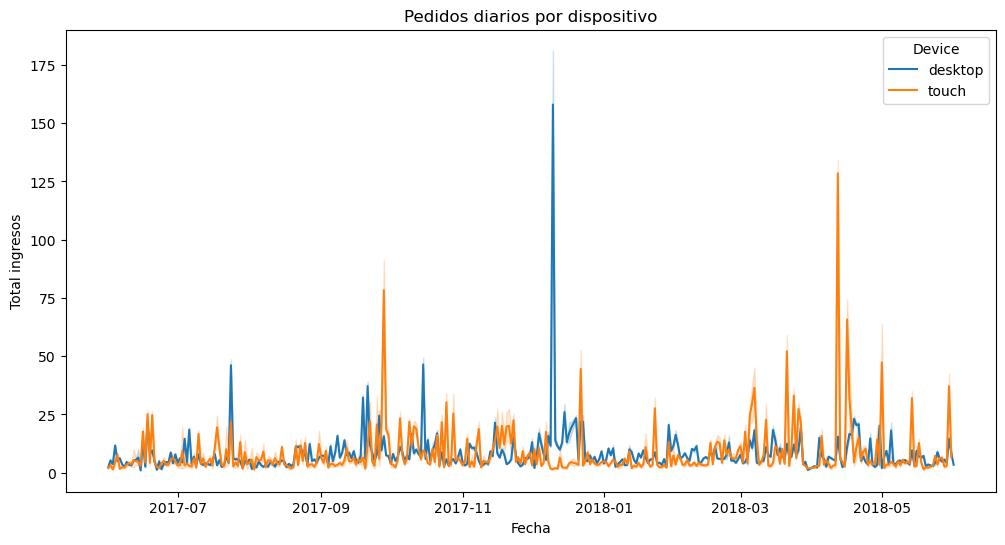

In [28]:
# Pedidos por día y dispositivo
daily_orders_device = visits.merge(orders, on='Uid', how='inner')
daily_orders_device['order_day'] = daily_orders_device['Buy Ts'].dt.date

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_orders_device, x='order_day', y='Revenue', hue='Device')
plt.title('Pedidos diarios por dispositivo')
plt.xlabel('Fecha')
plt.ylabel('Total ingresos')
plt.show()

En la gráfica podemos ver que se presentan tendencias similares, lo que sugiere que las campañas y picos de demanda afectan a todos los usuarios por igual, sin importar el dispositivo.

El pico más alto que se ve es a finales de noviembre o principios de diciembre sobretodo en dispositivos de escritorio, posiblemente asociado a promociones estacionales (Black Friday o fin de año).

Otros repuntes visibles en septiembre de 2017 y abril de 2018.

Usuarios touch (móviles/tablets) muestran picos de compra más frecuentes, aunque con valores más bajos.

Usuarios desktop tienden a realizar menos pedidos en cantidad, pero con picos más pronunciados (mayor volumen en fechas clave).

Los picos indican campañas promocionales o eventos estacionales que incrementan significativamente las ventas.

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


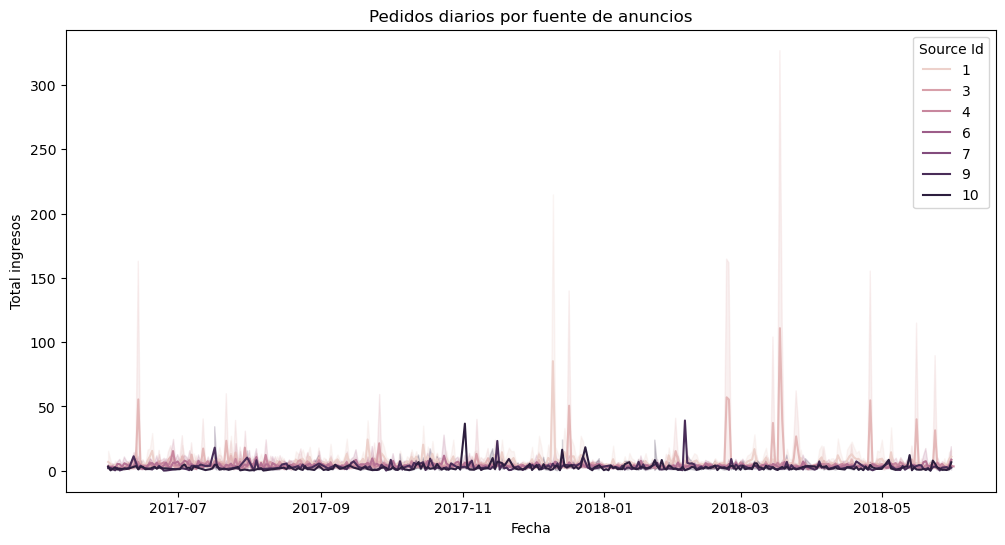

In [29]:
# Pedidos por fuente de anuncios a lo largo del tiempo
daily_orders_source = orders_with_source.copy()
daily_orders_source['order_day'] = daily_orders_source['Buy Ts'].dt.date

plt.figure(figsize=(12,6))
sns.lineplot(data=daily_orders_source, x='order_day', y='Revenue', hue='Source Id')
plt.title('Pedidos diarios por fuente de anuncios')
plt.xlabel('Fecha')
plt.ylabel('Total ingresos')
plt.show()

Podemos observar que la fuente 1 destaca claramente por su mayor volumen de pedidos diarios y picos más pronunciados, lo que coincide con su ROMI más alto de 3.88 y demuestra su rentabilidad.

Las fuentes 3 y 4 también presentan cierta actividad, pero con picos más dispersos y menos consistentes, reflejando baja rentabilidad y posibles campañas menos efectivas.

Se observan picos de actividad simultáneos entre fuentes en fechas específicas (por ejemplo, finales de noviembre y marzo), lo que sugiere campañas promocionales generales en esas fechas.



## Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde

### ¿Qué fuentes/plataformas recomendarías?  ¿Por qué? 

La recomendación más estratégica y la más rentable donde sugiero invertir es la Fuenta 1, con un ROMI de 3.88, lo que significa que por cada unidad monetaria invertida, se recuperan casi 4.

Además, mantiene un flujo constante de pedidos y usuarios, lo que indica buena calidad de tráfico y conversión.
Se recomienda aumentar la inversión en este canal y seguir optimizando sus campañas.

En la Fuente 2 su ROMI cercano a 0 indica que apenas cubre el gasto, pero podría tener potencial si se optimiza la segmentación o los mensajes publicitarios.
Se sugiere mantener una inversión controlada mientras se mejora la conversión.

Las fuentes 3, 4, 5, 9 y 10 deben revisarse o pausarse, ya que actualmente no generan retorno positivo.

En conjunto, se sugiere redirigir el presupuesto hacia las fuentes más eficientes y monitorear las métricas de CAC y ROMI de forma continua para asegurar la sostenibilidad del crecimiento.